<a href="https://colab.research.google.com/github/ibonetc/Data_Analytics/blob/main/Autoencoder_ImagenesMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Autoencoder

Basado en el ejercicio realizado en clases con las imágenes de MNIST, haga un modelo que sea capaz de reconocer una imagen con ruido. O sea, use las imágenes de MNIST, como un modelo no supervisado, de forma que pueda reconocer si una imagen con ruido. Después de entrenado el modelo, calcule el accuracy de esta clasificación final que usted obtiene con su propuesta, utilizando un conjunto de test con imágenes sin ruido e imágenes con ruido.
Pista para solución: Trate de unir las dos ideas dadas en clase para quitar ruido en imágenes y detectar anomalías en señales
1. Proponga un modelo y entrénelo.
1. Proponga una forma para con el resultado de la red saber si la imagen la puede clasificar en imagen buena o con ruido.
1. Evalúe esta propuesta con un conjunto de test compuesto con un porciento de las imágenes originales y éstas con un rango de ruido.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Reshape, Conv2DTranspose, Dropout
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [2]:
(x_train,_),(x_test,_)= mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [4]:
train_data= np.reshape(x_train, (len(x_train), 28, 28, 1))
test_data= np.reshape(x_test, (len(x_test), 28, 28, 1))

In [8]:
noisy_train_data = train_data + 0.3*np.random.normal(loc=0.0, scale=1.0, size=train_data.shape)
noisy_train_data = np.clip(noisy_train_data, 0., 1.)

noisy_test_data = test_data + 0.3*np.random.normal(loc=0.0, scale=1.0, size=test_data.shape)
noisy_test_data= np.clip(noisy_test_data, 0., 1.)

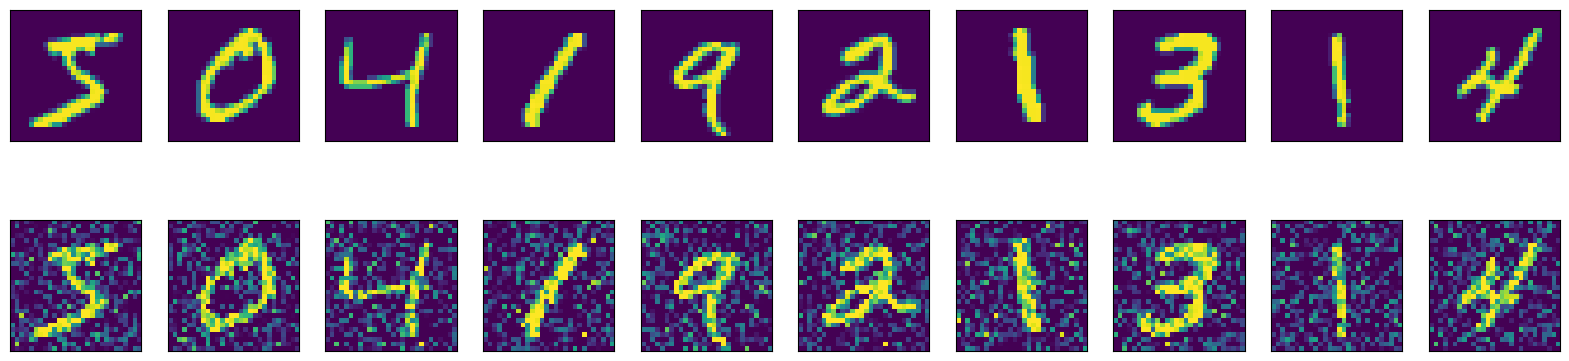

In [9]:
plt.figure(figsize=(20, 5))
for i in range(10):
  ax = plt.subplot(2, 10, i + 1)
  plt.imshow(train_data[i].reshape(28, 28))
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
  ax = plt.subplot(2, 10, i + 1 +10)
  plt.imshow(noisy_train_data[i].reshape(28, 28))
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()

In [10]:
input= Input(shape=(28,28,1))

# Encoder
encoder= Conv2D(64, (3,3), activation='relu', padding='same')(input)
encoder= MaxPooling2D((2,2), padding='same')(encoder)
encoder= Conv2D(32, (3,3), activation='relu', padding='same')(encoder)
encoder= MaxPooling2D((2,2), padding='same')(encoder)

# Decoder
decoder= Conv2DTranspose(32, (3,3), strides=2, activation='relu', padding='same')(encoder)
decoder= Conv2DTranspose(64, (3,3), strides=2, activation='relu', padding='same')(decoder)
decoder= Conv2D(1, (3,3), activation='sigmoid', padding='same')(decoder)

#Autoencoder

autoencoder= Model(input, decoder)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 14, 14, 32)     │         9,248 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 28, 28, 64)     │        18,496 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 1)      │           577 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,425 (185.25 KB)

 Trainable params: 47,425 (185.25 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
autoencoder.fit(x=train_data,
                y=train_data,
                epochs=50,
                batch_size=128)

Epoch 1/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - loss: 0.1239
Epoch 2/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0705
Epoch 3/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0684
Epoch 4/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0673
Epoch 5/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0666
Epoch 6/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0661
Epoch 7/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0656
Epoch 8/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0653
Epoch 9/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0649
Epoch 10/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0646
Epoch 11/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.0644
Epoch 12/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.0642
Epoch 13/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0640
Epoch 14/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0638
Epoch 15/50
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step

In [ ]:
reconstructions = autoencoder.predict(train_data)
train_loss = tf.keras.losses.mae(reconstructions, train_data)
result_train=[np.mean(i) for i in train_loss]

In [28]:
train_loss.shape

TensorShape([60000, 28, 28])

In [16]:
result_train=[np.mean(i) for i in train_loss]

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [31]:
len(result_train)

60000

In [15]:
reconstructions = autoencoder.predict(noisy_train_data)
train_loss_noisy = tf.keras.losses.mae(reconstructions, noisy_train_data)
result_noisy=[np.mean(i) for i in train_loss_noisy]

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


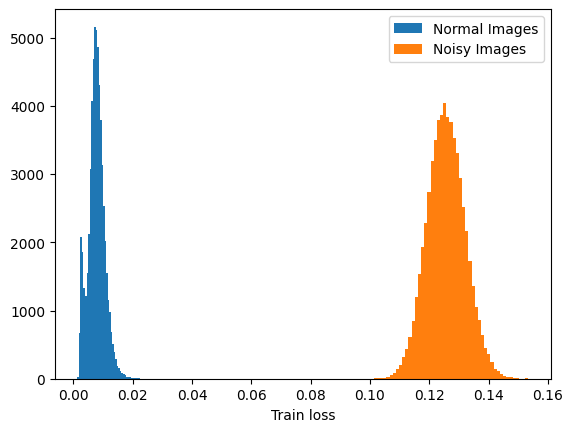

In [17]:
plt.hist(result_train, bins=50, label='Normal Images')
plt.hist(result_noisy, bins=50, label='Noisy Images')
plt.xlabel('Train loss')
plt.legend()
plt.show()

In [33]:
threshold= np.mean(result_train)+8*np.std(result_noisy)
print(threshold)

0.05892404301566114


In [21]:
label_test=np.concatenate((np.zeros(len(test_data)),np.ones(len(test_data))))

In [22]:
test_data_mixed=np.concatenate((test_data,noisy_test_data))

In [23]:
prediction_test=autoencoder.predict(test_data_mixed)

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


In [24]:
loss_prediction=tf.keras.losses.mae(prediction_test,test_data_mixed)
loss=[np.mean(i) for i in loss_prediction]

In [25]:
label_prediction=[0 if l<threshold else 1 for l in loss]

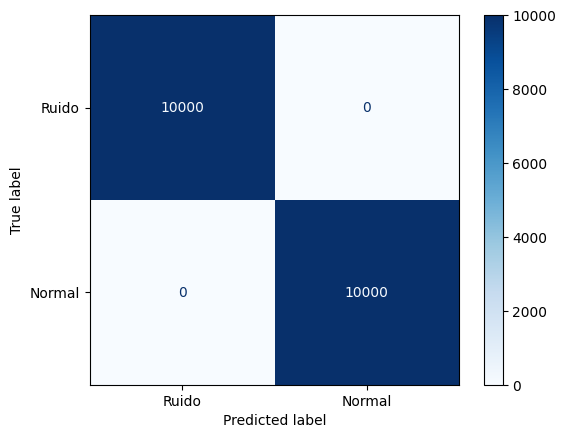

In [26]:
cm=confusion_matrix(label_test,label_prediction)
disp= ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ruido','Normal'])
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.show()

In [27]:
print(classification_report(label_test,label_prediction))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     10000
         1.0       1.00      1.00      1.00     10000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

